Iteration 1: Best path length - 3.285180655184888
Iteration 2: Best path length - 2.991375208476347
Iteration 3: Best path length - 2.8769155821660726
Iteration 4: Best path length - 2.8769155821660726
Iteration 5: Best path length - 2.8769155821660726
Iteration 6: Best path length - 2.8769155821660726
Iteration 7: Best path length - 2.8769155821660726
Iteration 8: Best path length - 2.8769155821660726
Iteration 9: Best path length - 2.755709561524994
Iteration 10: Best path length - 2.755709561524994
Iteration 11: Best path length - 2.755709561524994
Iteration 12: Best path length - 2.755709561524994
Iteration 13: Best path length - 2.594491498145528
Iteration 14: Best path length - 2.594491498145528
Iteration 15: Best path length - 2.594491498145528
Iteration 16: Best path length - 2.1902162697577836
Iteration 17: Best path length - 2.1902162697577836
Iteration 18: Best path length - 2.1902162697577836
Iteration 19: Best path length - 2.1902162697577836
Iteration 20: Best path length

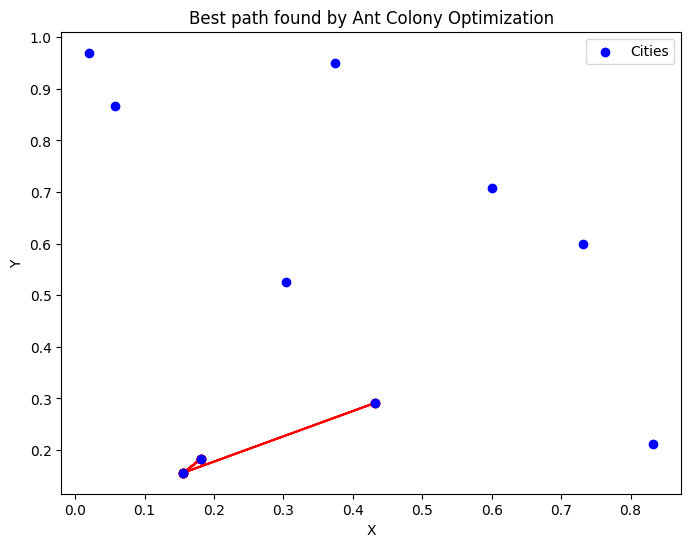

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

NUM_CITIES = 10
ITERATIONS= 100
ANT_COUNT = 50
ALPHA = 1
BETA = 5
RHO = 0.1
Q = 100

np.random.seed(42)
cities = np.random.rand(NUM_CITIES,2)

def calculate_distance(cities):
    dist_matrix = np.zeros((NUM_CITIES, NUM_CITIES))
    for i in range(NUM_CITIES):
        for j in range(NUM_CITIES):
            dist = np.linalg.norm(cities[i] - cities[j])
            dist_matrix[i][j] = dist_matrix[j][i] = dist
    return dist_matrix

def initialize_pheromones():
    pheromones = np.ones((NUM_CITIES, NUM_CITIES))
    np.fill_diagonal(pheromones, 0 )
    return pheromones

def select_next_city(current_city, visited, pheromones,distances):
    pheromone_levels = pheromones[current_city]
    pheromone_levels[visited] = 0

    desirability = pheromone_levels**ALPHA *(1.0/(distances[current_city] + 1e-10))**BETA

    total = np.sum(desirability)
    if total == 0:
        probabilities = np.ones_like(desirability) / len(desirability)
    else:
        probabilities = desirability / total

    next_city = np.random.choice(len(probabilities), p = probabilities)
    return next_city

def ant_colony_optimization():
    distances = calculate_distance(cities)
    pheromones = initialize_pheromones()

    best_path = None
    best_length = float('inf')

    for iteration in range(ITERATIONS):
        all_paths = []
        all_lengths = []

        
        for ant in range(ANT_COUNT):
            visited = [False]*NUM_CITIES
            path = []
            current_city = random.randint(0,NUM_CITIES -1)
            path.append(current_city)
            visited[current_city]=True

            for _ in range(NUM_CITIES -1):
                next_city = select_next_city(current_city,visited, pheromones, distances)
                path.append(next_city)
                visited[next_city] = True
                current_city = next_city

            path_length = sum(distances[path[i], path[i+1]] for i in range(NUM_CITIES - 1)) + distances[path[-1],path[0]]
            
            all_paths.append(path)
            all_lengths.append(path_length)

            if path_length< best_length:
                best_path = path
                best_length = path_length

        pheromones *= (1-RHO)

        for ant in range(ANT_COUNT):
            path = all_paths[ant]
            path_length = all_lengths[ant]
            pheromone_deposit = Q/path_length
            for i in range(NUM_CITIES -1):
                pheromones[path[i], path[i+1]] +=pheromone_deposit
            pheromones[path[-1],path[0]] +=pheromone_deposit

        print(f"Iteration {iteration + 1}: Best path length - {best_length}")
    
    return best_path, best_length


def plot_best_path(best_path):
    best_path_coords= cities[best_path]
    best_path_coords = np.vstack((best_path_coords, best_path_coords[0]))

    plt.figure(figsize = (8,6))
    plt.plot(best_path_coords[:,0], best_path_coords[:,1], 'r-o',markersize = 6)
    plt.scatter(cities[:,0], cities[:,1], color ='blue', label = 'Cities', zorder = 5)
    plt.title('Best path found by Ant Colony Optimization')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.show()

best_path, best_length  = ant_colony_optimization()
print(f"\nBest Path: {best_path}")
print(f"Best PAth Length: {best_length}")
plot_best_path(best_path)